# AG-HYPOPT · Trial 26

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-five trials are registered; cell 2 reports `phase = trials` (25/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074). Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** travel 0.138, `lr_gamma=0.4716`, `gamma_anneal=0.4723`; 0 div.
- next best: trial_22 0.1095 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138); all 0 div.
- plateau: trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_06 0.1188.
- diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: the best is a narrow spike at travel ~0.137-0.138 with balanced gamma knobs. Trial_25 (same travel 0.137, different `gamma_anneal`) fell back to 0.1126, so the spike is tight and the outcome varies by small cells. Low travel (<0.10) is worse and the source of sporadic divergences. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_26'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (25/5 trials)
ID |     ei | params
 1 | 0.2800 | {"gamma_anneal": 0.41202624468663085, "lr_gamma": 0.7272152936880081, "lr_mu": 0.1498871207939142, "mu_anneal": 0.34607753027476884}
 2 | 3.8238 | {"gamma_anneal": 0.46487064324721966, "lr_gamma": 0.4711193851666182, "lr_mu": 0.1653026566996843, "mu_anneal": 0.3451342624231235}
 3 | 2.5986 | {"gamma_anneal": 0.4314070740825271, "lr_gamma": 0.4582728072757864, "lr_mu": 0.1711381278350041, "mu_anneal": 0.3585526994589949}
 4 | 2.3175 | {"gamma_anneal": 0.49507116545787033, "lr_gamma": 0.39665293317760303, "lr_mu": 0.16107356965970288, "mu_anneal": 0.32382462318841737}
 5 | 2.5098 | {"gamma_anneal": 0.5636451577254509, "lr_gamma": 0.4161347319460962, "lr_mu": 0.17083709472639652, "mu_anneal": 0.349353423859412}
 6 | 2.1049 | {"gamma_anneal": 0.4594060999099934, "lr_gamma": 0.8028277130666818, "lr_mu": 0.16264791850199833, "mu_anneal": 0.3488768178972695}
 7 | 1.4146 | {"gamma_anneal": 0.44461410093075526, "lr_gamma": 0.42502

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (25 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 2: **ei 3.82** — `lr_mu=0.1653`, `mu_anneal=0.3451` (travel **0.137**), `lr_gamma=0.4711`, `gamma_anneal=0.4649`.
- candidate 8: ei 3.79 — `lr_mu=0.1541`, `mu_anneal=0.3494` (travel 0.127), `lr_gamma=0.4728`, `gamma_anneal=0.5344`.
- candidate 3: ei 2.60 — `lr_mu=0.1711`, `mu_anneal=0.3586` (travel 0.140), `lr_gamma=0.4583`, `gamma_anneal=0.4314`.
- candidate 5: ei 2.51 — `lr_mu=0.1708`, `mu_anneal=0.3494` (travel 0.141), `lr_gamma=0.4161`, `gamma_anneal=0.5636`.
- candidate 4: ei 2.32 — `lr_mu=0.1611`, `mu_anneal=0.3238` (travel 0.135), `lr_gamma=0.3967`.

Candidate 2 has the highest ei and is a near-exact copy of the best trial_21: `lr_mu` 0.1653 vs 0.1669, `mu_anneal` 0.3451 vs 0.3455, `lr_gamma` 0.4711 vs 0.4716, `gamma_anneal` 0.4649 vs 0.4723; travel 0.137 vs 0.138. It is the closest proposal to the campaign best yet produced, so it is the natural, low-risk resample. Candidate 8 is a close second at travel 0.127; candidates 3/4/5 are similar but with more divergent gamma knobs and lower ei. Choosing the maximum-ei candidate 2 (the best-point resample) is the sensible move.

I choose candidate 2 (2 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.46487064324721966, 'lr_gamma': 0.4711193851666182, 'lr_mu': 0.1653026566996843, 'mu_anneal': 0.3451342624231235}
Running  1nW Trans05 ... 

μ 9.39 -> 6.59 | γ 8.5 -> 30290892949496164.00 | NLL 1.28


Running  1nW Trans20 ... 

μ 17.32 -> 44.77 | γ 8.5 -> 6.11 | NLL 5.14


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 80.00 | γ 14.1 -> 14.58 | NLL 3.77


Running 3nW Trans100 ... 

μ 175.71 -> 109.82 | γ 14.1 -> 13.99 | NLL 3.42



Total: 8.5 min


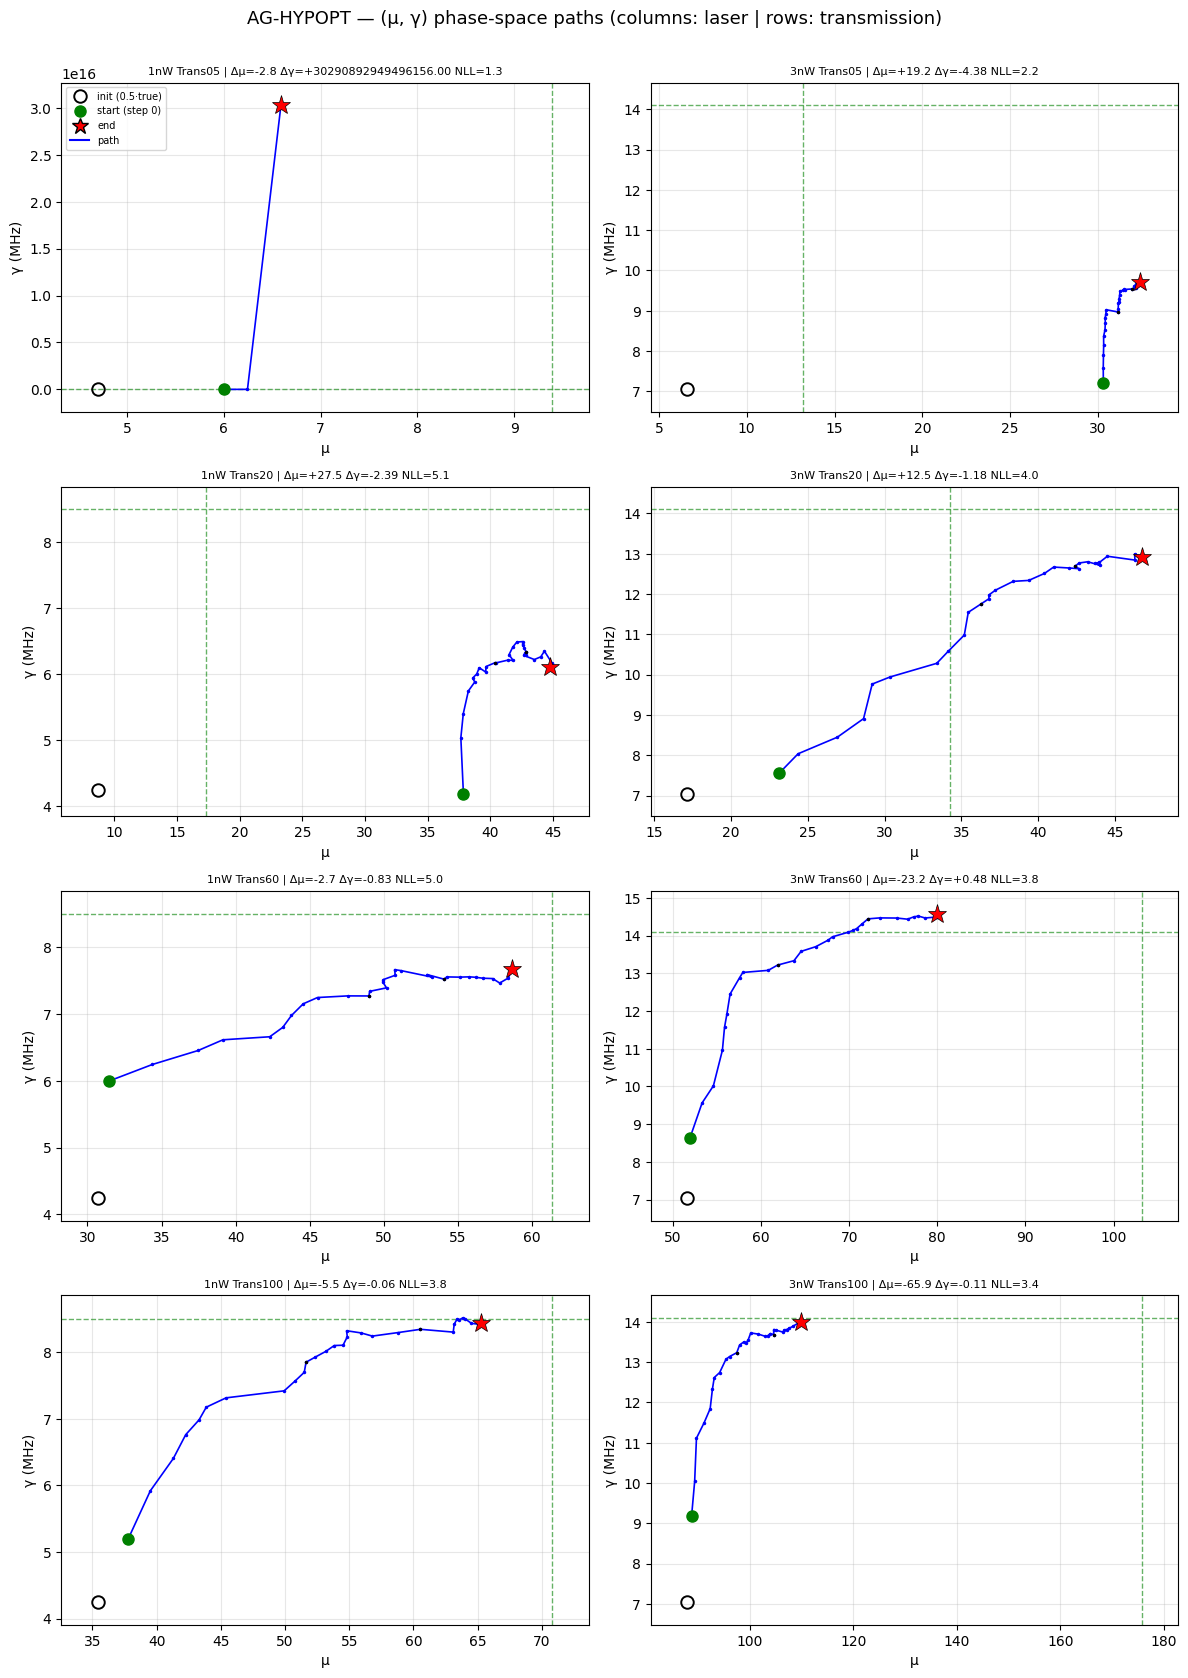

trial finished in 8.5 min
objective = 0.1368 ± 0.0968
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39    6.59   -29.8 |     8.5030290892949496164.00+356363446464660672.0
1nW Trans20       17.32   44.77  +158.5 |     8.50    6.11   -28.1
1nW Trans60       61.37   58.68    -4.4 |     8.50    7.67    -9.7
1nW Trans100       70.82   65.29    -7.8 |     8.50    8.44    -0.8
3nW Trans05       13.20   32.40  +145.4 |    14.10    9.72   -31.1
3nW Trans20       34.28   46.73   +36.3 |    14.10   12.92    -8.3
3nW Trans60      103.20   80.00   -22.5 |    14.10   14.58    +3.4
3nW Trans100      175.71  109.82   -37.5 |    14.10   13.99    -0.8

weighted objective (T-graded, cap=1.0) = 0.1368 | diverged cells: 1
μ: RMSE 27.844 (rel 79.4%, bias -5.126) | γ: RMSE 10709447906392256.000 (rel 125993504781085376.0%, bias +3786361618687018.500)


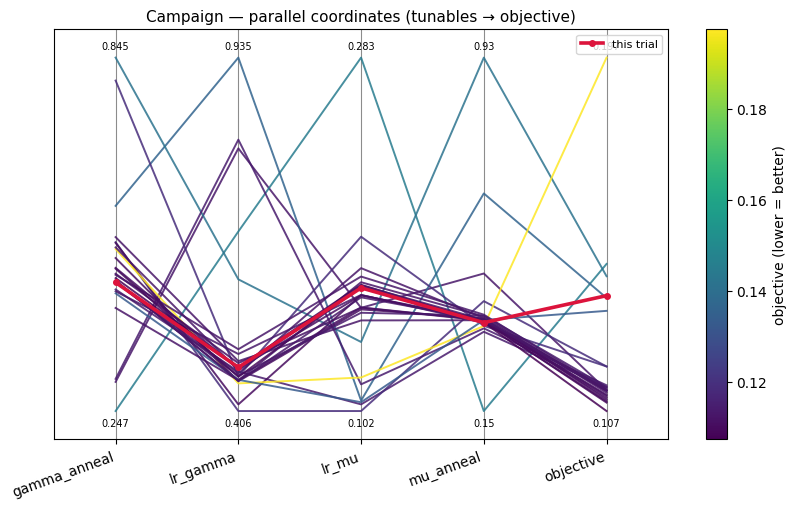

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 26 ran the highest-EI candidate (candidate 2, ei=3.82): `lr_mu=0.1653`, `mu_anneal=0.3451` (effective mu travel 0.137), `lr_gamma=0.4711`, `gamma_anneal=0.4649` — the closest proposal yet to the campaign best trial_21. It completed in 8.5 min with objective **0.1368 +/- 0.0968** and **1 diverged cell** (1nW T05: gamma 3.03e16). Ranking: trial_21 0.1074 < ... < **trial_26 0.1368** (worse than trial_03's 0.1362 by a hair) < ...

Aggregate accuracy: **mu rel-RMSE 79.4%** (RMSE 27.84, bias -5.13); gamma is dominated by the diverged cell (raw RMSE 1.07e16).

Per-cell relative errors (1nW T05 gamma is the diverged value):
- **mu:** 1nW T05 -29.8%, T20 +158.5%, T60 -4.4%, T100 -7.8% | 3nW T05 +145.4%, T20 +36.3%, T60 -22.5%, T100 -37.5%.
- **gamma:** 1nW T05 **diverged (3.03e16)**, T20 -28.1%, T60 -9.7%, T100 -0.8% | 3nW T05 -31.1%, T20 -8.3%, T60 +3.4%, T100 -0.8%.

This is a striking and important result. Trial 26 is a near-exact resample of the best run trial_21 — `lr_mu` 0.1653 vs 0.1669, `mu_anneal` 0.3451 vs 0.3455, `lr_gamma` 0.4711 vs 0.4716, `gamma_anneal` 0.4649 vs 0.4723 — yet it **diverged at 1nW T05**, the very cell trial_21 survived. The other seven cells behaved normally (like a typical 0.11-0.12 run). This shows the sporadic low-count gamma blow-up is essentially **unpredictable at the resolution of these four knobs**: a change of ~0.001-0.007 in the parameters flipped whether the cell stays finite. It follows that trial_21's divergence-free 0.1074 may be partly a favourable draw, and any claim about the best configuration should be read with that caveat.

**Summary:** Trial 26 (lr_mu=0.1653, mu_anneal=0.3451, lr_gamma=0.4711, gamma_anneal=0.4649): objective 0.1368 +/- 0.0968 with 1 diverged cell (1nW T05, gamma 3.0e16); despite being a near-exact copy of the best trial_21, it diverged at the very cell trial_21 survived.
**Key insight:** A near-exact resample of the best configuration (all four knobs within ~0.007 of trial_21) diverged at 1nW T05 while trial_21 did not, so the sporadic gamma blow-up is chaotic/unpredictable at this resolution and trial_21's divergence-free best result may be partly luck.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** This is the strongest evidence yet that the low-count gamma divergence is not a tunable property: two configurations within 0.007 of each other in every knob gave opposite outcomes at 1nW T05. It argues that the honest headline is the *typical* divergence-free level (~0.110-0.113) rather than a single lucky 0.1074, and that eliminating the divergence requires a structural safeguard (clip, damping, or per-cell handling) that is outside this campaign's scope. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 26 (lr_mu=0.1653, mu_anneal=0.3451, lr_gamma=0.4711, gamma_anneal=0.4649): objective 0.1368 +/- 0.0968 with 1 diverged cell (1nW T05, gamma 3.0e16); despite being a near-exact copy of the best trial_21, it diverged at the very cell trial_21 survived"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "A near-exact resample of the best configuration (all four knobs within ~0.007 of trial_21) diverged at 1nW T05 while trial_21 did not, so the sporadic gamma blow-up is chaotic/unpredictable at this resolution and trial_21's divergence-free best result may be partly luck"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_26 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_27.ipynb. Open it and follow its cells from the top.
